# 🧩 Mixture of Experts & Expert Parallelism

[Sam Foreman](https://samforeman.me)
(\[[ALCF](https://alcf.anl.gov/about/people/sam-foreman)\](<https://alcf.anl.gov/about/people/sam-foreman>))  
2026-07-22

> **Authors**
>
> Written by [Sam Foreman](https://samforeman.me) for the [Intro to HPC
> Bootcamp](https://intro-hpc-bootcamp.alcf.anl.gov/).

[](https://colab.research.google.com/github/saforem2/intro-hpc-bootcamp/blob/main/docs/03-advanced-llms/0-moe/index.ipynb)
[](https://github.com/saforem2/intro-hpc-bootcamp/blob/main/content/03-advanced-llms/0-moe/index.qmd)

By now you have seen how to split a model across many GPUs in [\[02.1\]
Distributed
Training](../../01-neural-networks/5-distributed-training/index.qmd):
data parallelism (DDP), ZeRO/FSDP, tensor parallelism (TP), pipeline
parallelism (PP), and sequence parallelism (SP). Every one of those
strategies keeps the model **dense** — each token flows through *every*
parameter.

**Mixture of Experts (MoE)** breaks that assumption. Instead of one big
feed-forward network (FFN), an MoE layer holds *many* FFN “experts” and
a small **router** that sends each token to only a *few* of them. The
model can have enormous total capacity while each token only pays for a
tiny slice of it. This is how
[DeepSeek-v3](https://arxiv.org/abs/2412.19437) reaches **671B total
parameters** while activating only **~37B per token**.

This lab follows the usual arc:

1.  **① A toy that really runs** — a from-scratch top-2-of-4 MoE layer
    on CPU.
2.  **② The real thing** — the annotated DeepSeek-v3 MoE block + a
    torchtitan config.
3.  **③ Scale it up** — launch an MoE run with **expert parallelism**
    via `ezpz`.

## 🧠 What is a Mixture of Experts?

A dense transformer block is `attention → FFN`. An MoE block replaces
that one FFN with:

- **$E$ experts** — independent FFNs, e.g. $E = 256$.
- A **router** (a.k.a. *gate*) — a tiny linear layer that scores each
  token against all $E$ experts.
- **Top-$k$ routing** — each token is sent to only its best $k$ experts
  (e.g. $k = 2$), so most experts are *skipped* for any given token.
  This is **sparse activation**.

Because only $k$ of $E$ experts run per token, the **activated**
parameter count scales with $k$, not $E$:

$$P_\text{active} \;\approx\; P_\text{attn+embed} \;+\; \frac{k}{E}\, P_\text{experts}$$

The catch: if the router sends *every* token to the same one or two
popular experts, the rest sit idle and you have wasted your parameters.
We fix that with an **auxiliary load-balancing loss** and a **capacity
factor** (both below).

## 👋 ① A toy that really runs

Let’s build a complete MoE layer in a few dozen lines of pure PyTorch —
small enough to run on a laptop CPU. It has all four moving parts: a
**router**, **sparse dispatch** to expert FFNs, a weighted **combine**,
and the **load-balancing loss**.

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from rich import print

torch.manual_seed(0)


class Expert(nn.Module):
    """A single expert: an ordinary position-wise FFN."""

    def __init__(self, d_model: int, d_hidden: int):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(d_model, d_hidden),
            nn.GELU(),
            nn.Linear(d_hidden, d_model),
        )

    def forward(self, x):
        return self.net(x)

Now the MoE layer itself. Read the four numbered steps in `forward`:

In [3]:
class MoELayer(nn.Module):
    def __init__(self, d_model=8, d_hidden=16, n_experts=4, top_k=2):
        super().__init__()
        self.n_experts = n_experts
        self.top_k = top_k
        # the router / gate: scores every token against every expert
        self.gate = nn.Linear(d_model, n_experts, bias=False)
        self.experts = nn.ModuleList(
            [Expert(d_model, d_hidden) for _ in range(n_experts)]
        )

    def forward(self, x):
        # x: (n_tokens, d_model)
        # 1. ROUTER: score each token against all experts
        logits = self.gate(x)                       # (n_tokens, n_experts)
        probs = F.softmax(logits, dim=-1)           # (n_tokens, n_experts)

        # 2. TOP-K: keep only the k best experts per token (sparse activation)
        topk_probs, topk_idx = probs.topk(self.top_k, dim=-1)  # (n_tokens, k)
        # renormalize the kept gate weights so they sum to 1 per token
        topk_probs = topk_probs / topk_probs.sum(dim=-1, keepdim=True)

        # 3. DISPATCH + COMBINE: run each expert on just its tokens, sum results
        out = torch.zeros_like(x)
        counts = torch.zeros(self.n_experts, dtype=torch.long)
        for e in range(self.n_experts):
            mask = topk_idx == e                    # (n_tokens, k)
            token_ids, slot_ids = mask.nonzero(as_tuple=True)
            counts[e] = token_ids.numel()
            if token_ids.numel() == 0:
                continue  # this expert got no tokens this step
            expert_out = self.experts[e](x[token_ids])          # batched FFN
            weights = topk_probs[token_ids, slot_ids].unsqueeze(-1)
            out.index_add_(0, token_ids, expert_out * weights)  # weighted combine

        # 4. AUXILIARY LOAD-BALANCING LOSS (Switch Transformer, Eq. 4)
        #    f_i = fraction of dispatched tokens going to expert i
        #    P_i = mean router probability mass on expert i
        #    minimized (== 1.0) when load is perfectly uniform
        P = probs.mean(dim=0)                                    # (n_experts,)
        dispatch = F.one_hot(topk_idx, self.n_experts).float()  # (n_tokens, k, E)
        f = dispatch.sum(dim=(0, 1)) / dispatch.sum()           # (n_experts,)
        aux_loss = self.n_experts * torch.sum(P * f)
        return out, aux_loss, counts

Run it on a tiny batch of 12 tokens and inspect **per-expert
utilization** — the single most important thing to watch when training
an MoE:

In [4]:
n_tokens, d_model = 12, 8
x = torch.randn(n_tokens, d_model)

moe = MoELayer(d_model=d_model, d_hidden=16, n_experts=4, top_k=2)
out, aux_loss, counts = moe(x)

print(f"input shape : {tuple(x.shape)}")
print(f"output shape: {tuple(out.shape)}")
print(f"aux load-balancing loss: {aux_loss.item():.4f}  (1.0 == perfectly balanced)")
print(f"total dispatches: {counts.sum().item()}  (== n_tokens x top_k = {n_tokens * moe.top_k})")
print("\nper-expert token counts (top-2 of 4):")
total = counts.sum().item()
for e, c in enumerate(counts.tolist()):
    print(f"  expert {e}: {c:2d} tokens  {c / total:6.1%}  {'#' * c}")

input shape : ( 12 , 8 )

output shape: ( 12 , 8 )

aux load-balancing loss: 1.0053 ( 1.0 == perfectly balanced )

total dispatches: 24 ( == n_tokens x top_k = 24 )

per-expert token counts ( top- 2 of 4 ) :

expert 0 : 6 tokens 25.0 % ######

expert 1 : 8 tokens 33.3 % ########

expert 2 : 5 tokens 20.8 % #####

expert 3 : 5 tokens 20.8 % #####

A few things to notice:

- Each of the 12 tokens went to **2** experts, so there are
  `12 x 2 = 24` dispatches spread over 4 experts.
- With a *random, untrained* router the load is already lumpy. During
  training, the **aux loss** term pushes the distribution toward uniform
  (loss $\to 1.0$).
- Each expert runs **once**, batched over only the tokens routed to it —
  that is the sparsity payoff.

### 📦 Capacity factor

On real hardware an expert’s buffer is a **fixed-size tensor**, so we
cap how many tokens each expert may accept. That cap is set by the
**capacity factor**:

$$\text{capacity} \;=\; \Big\lceil \text{capacity\_factor} \times \frac{\text{tokens} \times k}{E} \Big\rceil$$

In [5]:
capacity_factor = 1.25
capacity = int(capacity_factor * n_tokens * moe.top_k / moe.n_experts)
print(f"expert capacity (cf={capacity_factor}): {capacity} tokens/expert")
print("tokens beyond capacity are 'dropped' (skip the expert, kept via residual).")

expert capacity ( cf = 1.25 ) : 7 tokens/expert

tokens beyond capacity are 'dropped' ( skip the expert, kept via residual ) .

- `capacity_factor = 1.0` means “exactly the average load”; anything
  above the cap is **dropped** (it skips the expert and passes through
  the residual connection).
- Larger capacity → fewer dropped tokens but more wasted compute/memory
  on padding. Typical values are `1.0`–`2.0`.

> **🔬 At DeepSeek-v3 scale…**
>
> The toy above has 4 experts and 12 tokens on one CPU. DeepSeek-v3 has
> **256 routed experts + 1 shared expert per MoE layer**, routes
> **top-8**, and streams **millions of tokens per step** across
> thousands of GPUs. The `for e in range(n_experts)` Python loop becomes
> a single fused **grouped GEMM**, and the “dispatch tokens to experts”
> step becomes an **all-to-all** collective across the network — because
> the experts no longer live on the same GPU. That is *expert
> parallelism*, the subject of movement ③.

## 🏗️ ② The real thing: DeepSeek-v3

[DeepSeek-v3](https://arxiv.org/abs/2412.19437) (Dec 2024) is the
reference MoE LLM: **671B total parameters, ~37B activated per token**,
trained on 14.8T tokens in FP8. Its MoE block refines the toy above with
four key ideas.

<figure id="fig-deepseek-moe">
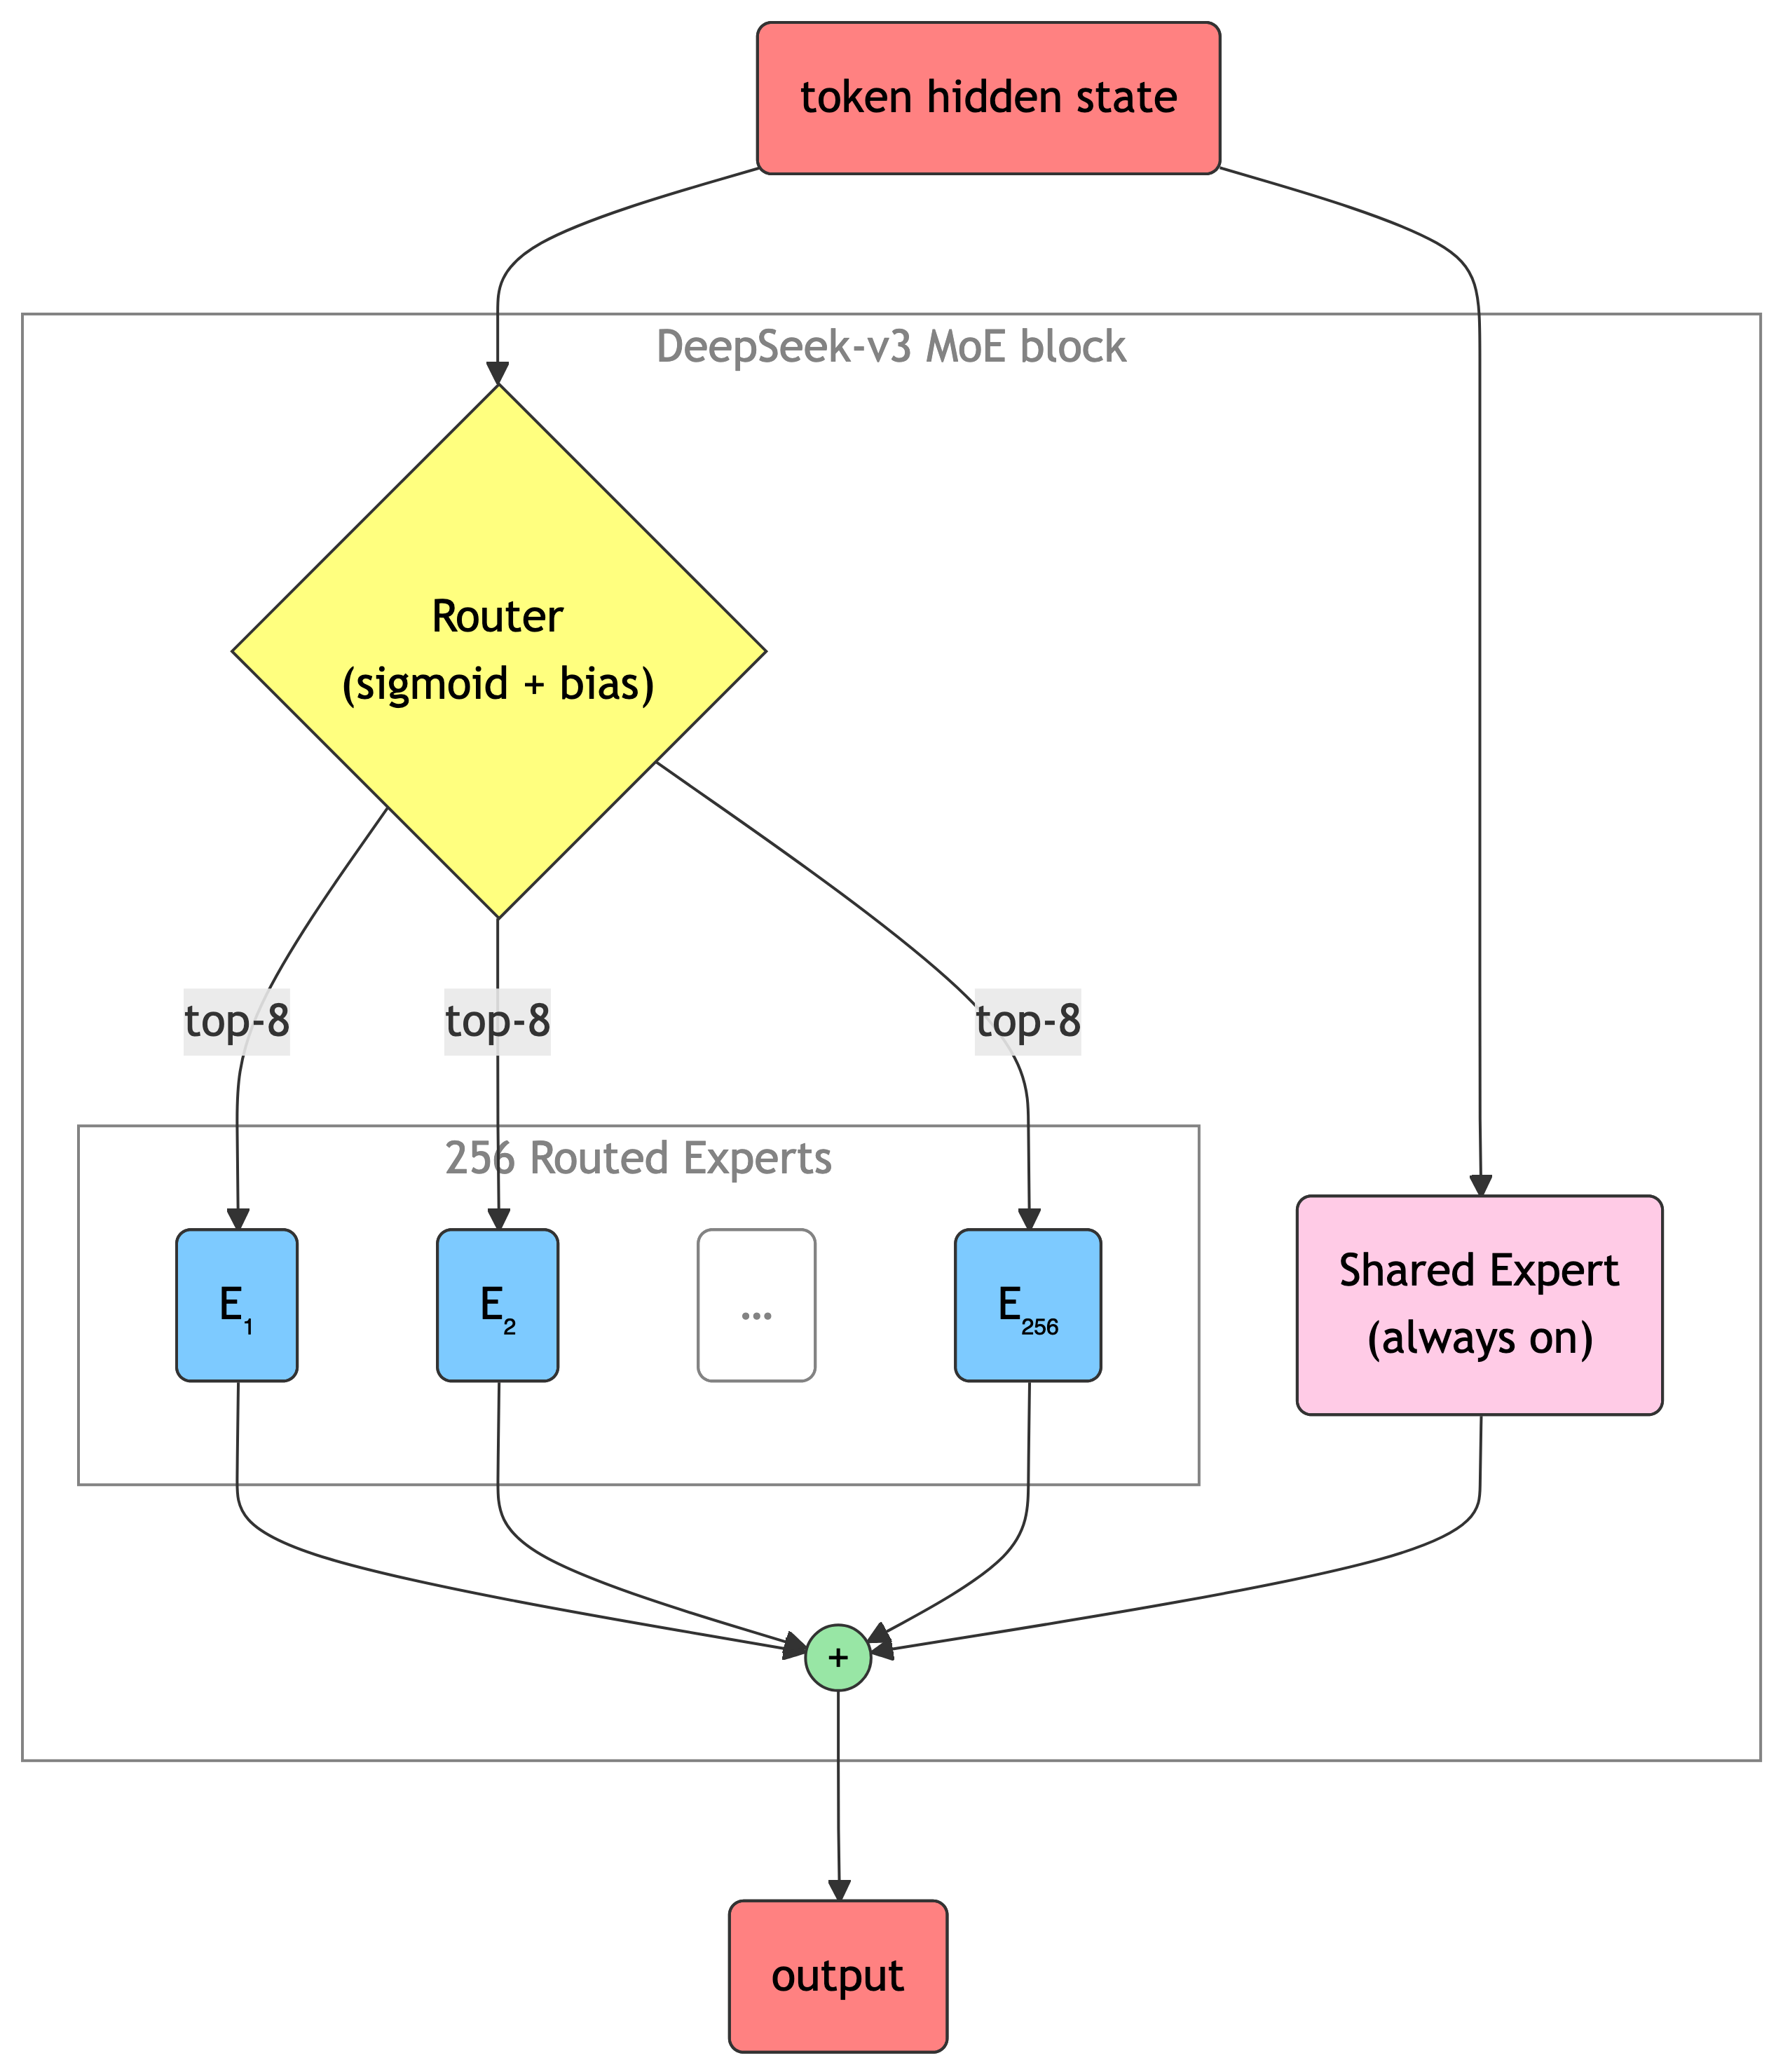
<figcaption>Figure 1: The DeepSeek-v3 MoE block: a <strong>shared
expert</strong> (always active) plus <strong>8 of 256 routed
experts</strong>, combined additively.</figcaption>
</figure>

1.  **Shared + routed experts.** One **shared expert** processes *every*
    token (capturing common knowledge), while **8 of 256 routed
    experts** are selected per token. This is the “DeepSeekMoE”
    fine-grained + shared-expert design.
2.  **Multi-head Latent Attention (MLA).** Attention keys/values are
    compressed into a small **latent vector** via low-rank projection,
    shrinking the KV-cache dramatically at inference — orthogonal to MoE
    but part of the same model.
3.  **Auxiliary-loss-free load balancing.** Instead of the aux loss from
    our toy (which adds gradient noise), DeepSeek-v3 adds a per-expert
    **bias term** to the routing scores and nudges it up/down each step
    to equalize load. No extra loss term, no interference with the
    language-modeling objective.
4.  **Multi-Token Prediction (MTP).** Extra lightweight heads predict
    *several* future tokens per position, densifying the training signal
    and enabling speculative decoding at inference.

### 🧾 A torchtitan MoE config (display-only)

[torchtitan](https://github.com/pytorch/torchtitan) ships a
`deepseek_v3` model with a MoE block controlled from the job’s TOML.
This is a representative excerpt — **display only** (torchtitan is not
installed in the build environment):

``` toml
[job]
description = "DeepSeek-v3-style MoE training"

[model]
name = "deepseek_v3"
flavor = "16B"                 # a small debug flavor; the full model is 671B
tokenizer_path = "./assets/tokenizer/tokenizer.json"

[model.moe]
num_experts = 256              # routed experts
num_shared_experts = 1         # always-on shared expert
top_k = 8                      # routed experts activated per token
score_func = "sigmoid"         # DeepSeek-v3 gating
route_norm = true              # renormalize the top-k gate weights
load_balance_coeff = 1e-3      # aux-loss-FREE: speed of the per-expert bias update

[training]
seq_len = 4096
local_batch_size = 8
steps = 10000
dtype = "bfloat16"

[parallelism]
data_parallel_shard_degree = -1   # FSDP over whatever ranks are left
tensor_parallel_degree = 1
expert_parallel_degree = 8        # <-- shard the 256 experts across 8 ranks
pipeline_parallel_degree = 1

[checkpoint]
enable = true                     # torchtitan uses Distributed Checkpoint (DCP)
interval = 500
```

### 📊 Dense vs. MoE: params and FLOPs

The whole point of MoE is decoupling **total** capacity from
**per-token** cost:

| Quantity                 | Dense (Llama-3 70B) |   MoE (DeepSeek-v3)   |
|:-------------------------|:-------------------:|:---------------------:|
| Total parameters         |         70B         |       **671B**        |
| Activated params / token |         70B         |       **~37B**        |
| FFN experts              |          1          | 256 routed + 1 shared |
| Experts active / token   |          —          |  8 routed + 1 shared  |
| FLOPs / token            |    $\propto$ 70B    |     $\propto$ 37B     |
| Activation ratio         |        100%         |       **~5.5%**       |

Table 1: Dense vs. MoE at comparable quality: MoE stores far more
knowledge for a similar per-token compute budget.

The activation ratio is exactly the sparsity we saw in the toy, scaled
up:

$$\frac{P_\text{active}}{P_\text{total}} \;=\; \frac{37\text{B}}{671\text{B}} \;\approx\; 5.5\%$$

A dense model with 671B parameters would cost **~18×** more FLOPs per
token than DeepSeek-v3 — which is why nobody trains one.

## 🚀 ③ Scale it up: expert parallelism

Sparse activation is a *math* trick; **expert parallelism (EP)** is the
*systems* trick that makes it fast. With 256 experts you cannot fit them
all on one GPU, so you **shard the experts across GPUs** — e.g. 32
experts per GPU across 8 ranks (`expert_parallel_degree = 8`).

The consequence: after the router picks each token’s experts, the
token’s hidden state must physically **travel to the GPU that owns its
expert**, run there, and come back. That round trip is a pair of
**all-to-all** collectives.

<figure id="fig-expert-parallel">
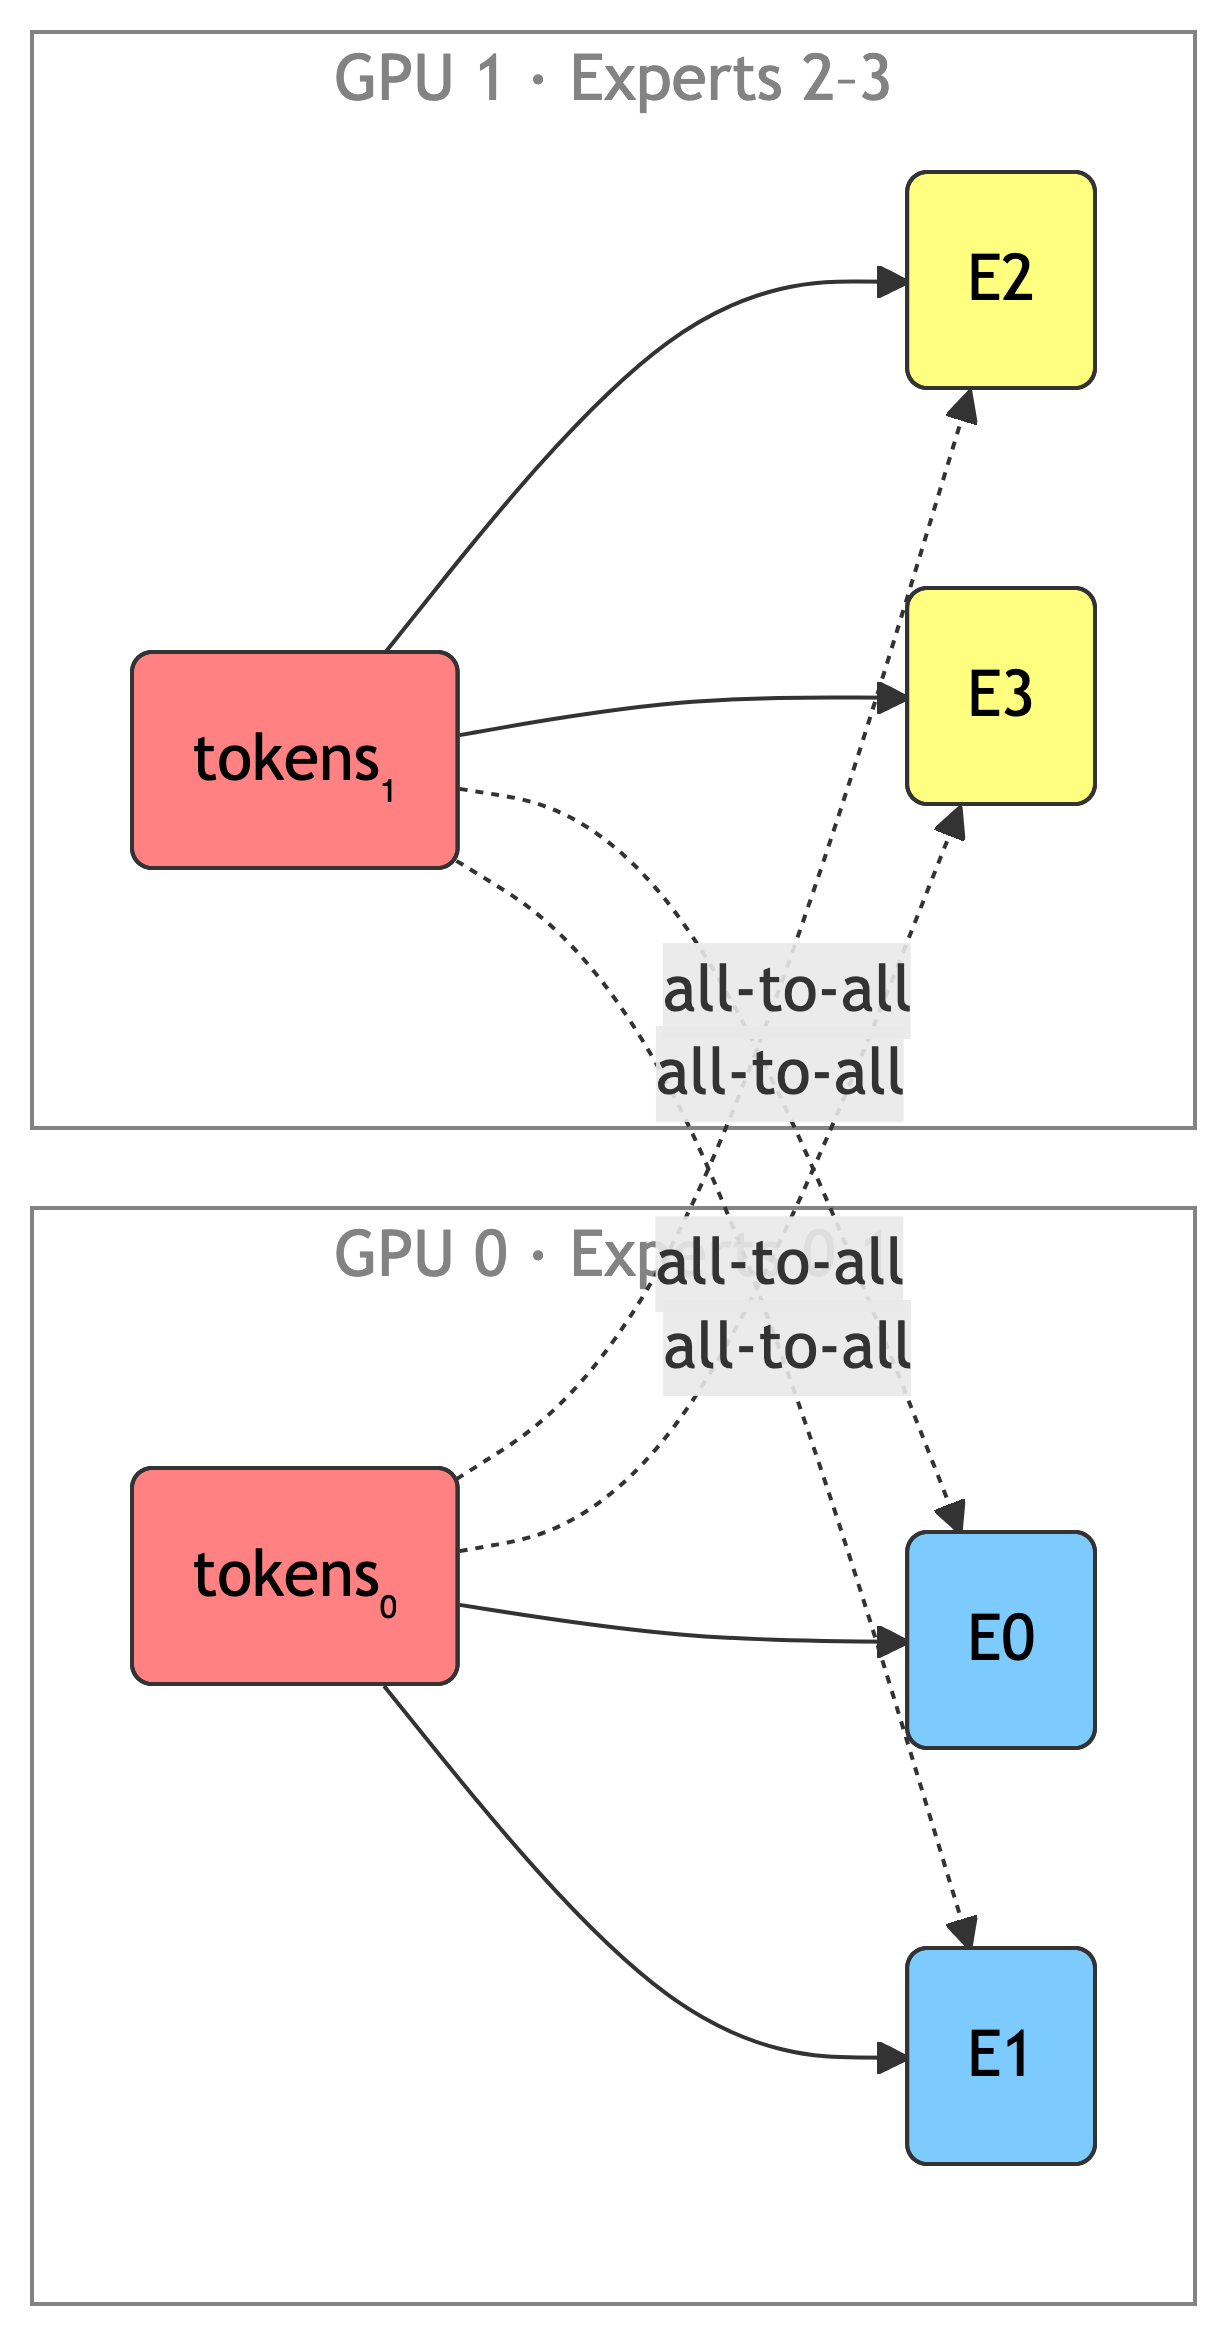
<figcaption>Figure 2: Expert parallelism: each GPU owns a <strong>subset
of experts</strong>. Tokens are shuffled to the right GPU with an
<strong>all-to-all</strong> (dispatch), computed, then shuffled back
(combine).</figcaption>
</figure>

### 🧭 EP vs. the parallelism you already know

| Strategy | What is split | Dominant collective | Replicated? |
|:--------|:---------------------------------|:------------------|:----------|
| **DP** | the *data* (each rank sees a shard) | `all-reduce` (grads) | full model |
| **TP** | *within* a layer’s weight matrices | `all-reduce` / `all-gather` | per-layer |
| **PP** | *across* layers (stages) | point-to-point | per-stage |
| **EP** | the *experts* of the MoE FFN | **`all-to-all`** | non-expert params |

How expert parallelism relates to the parallelism strategies from
[\[02.1\]](../../01-neural-networks/5-distributed-training/index.qmd)
{.table-responsive .table-striped .table-hover}

- **EP vs. DP/FSDP.** DP/FSDP replicate or shard the *same* dense
  weights; EP gives each rank *different* expert weights. In practice
  you run **EP inside a data-parallel world** — the attention and
  shared-expert params are still FSDP-sharded, only the routed experts
  use EP.
- **EP vs. TP.** TP splits a *single* weight matrix and needs an
  `all-reduce` every layer. EP keeps each expert whole on one rank and
  pays **`all-to-all`** only at the MoE block. All-to-all moves
  *tokens*, not weights.
- **When EP helps.** When (a) the model is MoE, (b) the experts don’t
  fit on one GPU, and (c) your interconnect can absorb the all-to-all.
  On slow networks the all-to-all becomes the bottleneck — this is
  exactly the *communication-vs-computation* tradeoff from
  [\[02.1\]](../../01-neural-networks/5-distributed-training/index.qmd).

### 🛠️ Launch it with `ezpz`

`ezpz` sets up the distributed environment and launches on any scheduler
(PBS → `mpiexec`, SLURM → `srun`, auto-detected). All commands below are
**display-only** — run them on a login node of an ALCF/NERSC system.

1.  Set up a system-agnostic environment and install deps:

    ``` bash
    source <(curl -fsSL https://bit.ly/ezpz-utils) && ezpz_setup .venv
    uv pip install git+https://github.com/saforem2/ezpz
    uv pip install git+https://github.com/pytorch/torchtitan
    ```

2.  Smoke-test the distributed setup before burning an allocation:

    ``` bash
    ezpz test
    ```

3.  (Optional, at scale) Stage the environment to node-local `/tmp` so
    every node imports fast:

    ``` bash
    ezpz yeet --compress --min-success-nodes 1
    ```

4.  Launch a DeepSeek-v3-style MoE run with **expert parallelism = 8**:

    ``` bash
    ezpz launch python3 -m torchtitan.train \
        --job.config_file ./train_configs/deepseek_v3_moe.toml \
        --parallelism.expert_parallel_degree 8 \
        --parallelism.data_parallel_shard_degree -1 \
        --training.steps 200 \
        --training.seq_len 4096 \
        --metrics.log_freq 10 \
        --profiling.enable_profiling
    ```

    `ezpz launch` figures out the node/GPU count and the right launcher
    for you — no `mpirun -n $NGPUS` needed. Add `-A <project>` to your
    job submission (e.g. NERSC Perlmutter `m4388`) as usual.

5.  For long jobs, run under fault tolerance so a dead node fails over
    to a spare:

    ``` bash
    ezpz launch --auto-retry --spare-nodes auto \
        python3 -m torchtitan.train --job.config_file ./train_configs/deepseek_v3_moe.toml
    ```

A healthy run prints per-step throughput and MFU, roughly:

``` bash
[step=10]  loss=6.214  tokens/sec=48213  tflops=182.4  mfu=39.7%
[step=20]  loss=5.977  tokens/sec=49030  tflops=185.5  mfu=40.4%
```

> **⏰ Watch expert utilization**
>
> The #1 MoE failure mode is **router collapse**: a few experts get all
> the tokens and the rest die. Watch per-expert token counts (torchtitan
> logs them) the same way you watched `counts` in the toy — they should
> stay roughly uniform. If they collapse, your aux-loss coefficient (or
> DeepSeek’s bias-update speed `load_balance_coeff`) is too small.

## 🎒 Homework

Submit **proof** that you launched a small MoE training run with expert
parallelism and report two numbers: **expert utilization** and
**tokens/sec**.

Concretely:

1.  Launch the movement ③ command with a small flavor
    (e.g. `--training.steps 200`, `expert_parallel_degree` matching your
    node’s GPU count).
2.  Report the **per-expert token counts / utilization** over training —
    do the experts stay balanced, or does the router collapse?
3.  Report the steady-state **tokens/sec** (and `mfu` if shown).

Where **proof** can be any of:

- The contents printed to your terminal during the run.
- A path to a logfile on the ALCF/NERSC filesystems.
- A screenshot of the throughput / expert-utilization output or a W&B
  chart.
- A URL to a [W&B](https://wandb.ai) Run or Report.

**Stretch goals:**

- Re-run with `expert_parallel_degree 1` vs. `2` vs. `4` and plot
  tokens/sec vs. EP degree. Where does the all-to-all start to hurt?
- The movement ① toy already runs on CPU. Sweep `top_k` (1, 2, 3) and
  `capacity_factor` in it and show how the aux loss and per-expert
  counts change as you make routing denser or sparser.

## 📚 References

- DeepSeek-AI. *DeepSeek-V3 Technical Report*.
  [arXiv:2412.19437](https://arxiv.org/abs/2412.19437)
- Fedus, Zoph, Shazeer. *Switch Transformers: Scaling to Trillion
  Parameter Models with Simple and Efficient Sparsity*.
  [arXiv:2101.03961](https://arxiv.org/abs/2101.03961)
- Lepikhin et al. *GShard: Scaling Giant Models with Conditional
  Computation and Automatic Sharding*.
  [arXiv:2006.16668](https://arxiv.org/abs/2006.16668)
- Zoph et al. *ST-MoE: Designing Stable and Transferable Sparse Expert
  Models*. [arXiv:2202.08906](https://arxiv.org/abs/2202.08906)
- Shazeer et al. *Outrageously Large Neural Networks: The Sparsely-Gated
  Mixture-of-Experts Layer*.
  [arXiv:1701.06538](https://arxiv.org/abs/1701.06538)
- torchtitan team. *torchtitan: One-stop PyTorch native solution for
  production-ready LLM pre-training*.
  [arXiv:2410.06511](https://arxiv.org/abs/2410.06511) ·
  [pytorch/torchtitan](https://github.com/pytorch/torchtitan)
-  [saforem2/ezpz](https://github.com/saforem2/ezpz)
- ⏪ Prerequisite: [\[02.1\] Distributed
  Training](../../01-neural-networks/5-distributed-training/index.qmd)

Last updated: 2026 - 07 - 22 10:03